# Tarea 2 - 2026
**Curso:** DAML 

**Fecha de entrega:** 25/05/2026

**Nombre:** Vicente Carrasco Pereira

---

**P1: Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

El dataset original contiene 12.040 observaciones y 41 variables, abarcando el período del 17 de febrero de 2020 al 17 de octubre de 2022. El panel incluye 86 ciudades de 5 países (DE, ES, FR, IT, SE) a lo largo de 140 semanas. Las variables son mayoritariamente numéricas (28 en formato `float64` y 8 en `int64`), con cuatro variables de texto identificadoras y una de fecha. En cuanto a datos faltantes, solo dos variables presentan valores ausentes: `edu2` y `edu3`, ambas con 5.460 faltantes (45.35%), que corresponden exactamente a todas las observaciones de Alemania.

El hallazgo más crítico de la exploración es que las cinco variables de política (`Valor_Stringency_Index`, `Valor_GovernmentResponseIndex`, `Valor_EconomicSupportIndex`, `Valor_Containment_Health_index` y `workplace_closing`) son idénticamente cero para Alemania en la totalidad de sus 5.460 observaciones. En los demás países, el Stringency Index promedia entre 40 y 57 puntos con desviaciones estándar de 20 o más, reflejando variación temporal sustantiva. Esto representa un error de fuente de datos, por lo que mantener Alemania anularía artificialmente el regresor de interés en esas observaciones, induciendo atenuación del coeficiente estimado.

En base a este diagnóstico se tomaron las siguientes decisiones de limpieza. Primero, se eliminaron las 5.460 observaciones de Alemania (45.3% del total). Segundo, se eliminaron `edu2` y `edu3`, que resultaban completamente faltantes una vez removidas las observaciones alemanas. Tercero, se eliminaron las variables `d1` a `d6`, sin documentación en el diccionario, presentes solo en ES y SE, y con correlaciones inferiores a 0.08 con las variables de política. Tras la limpieza el panel queda con 6.580 observaciones, 47 ciudades y 140 semanas, perfectamente balanceado (16 ciudades en ES, 15 en FR, 14 en IT y 2 en SE).

Como variables auxiliares se construyeron el logaritmo natural de la población (`log_pop`), dummies de país con España como categoría de referencia (`country_FR`, `country_IT`, `country_SE`) y dummies de año con 2020 como referencia (`year_2021`, `year_2022`).

La selección de variables para los modelos se realizó con criterio teórico, no mediante selección automática. Se excluyeron `Valor_GovernmentResponseIndex`, `Valor_Containment_Health_index` y `workplace_closing` por tener correlaciones superiores a 0.85 con `Valor_Stringency_Index`, generando multicolinealidad severa (el Stringency Index ya las resume de forma comprehensiva). Se excluyeron `industry` y `agriculture` por no aportar variación independiente respecto a las dummies de país, mientras que `construction` captura mejor el canal de no-teletrabajabilidad. Se excluyeron `unemp`, `f_unemp` y `m_unemp` por correlaciones mutuas superiores a 0.95. Finalmente, `sex_ratio` y `young_age_dependency` se descartaron por carecer de un canal teórico claro sobre la movilidad laboral en contexto pandémico. El conjunto final de variables (`Valor_Stringency_Index`, `daily_cases`, `log_pop`, `construction`, `old_age_dependency`, `foreigners`, dummies de país y año) fue verificado mediante el Factor de Inflación de la Varianza, obteniendo un máximo de 5.59 para `old_age_dependency`, con todos los valores por debajo del umbral crítico de 10, confirmando la ausencia de multicolinealidad severa.





---

**P2: Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

El modelo Pooled OLS se estimó con errores estándar clusterizados two-way (ciudad y tiempo) para corregir la correlación serial y la correlación contemporánea entre ciudades. La especificación incluye `Valor_Stringency_Index` como regresor de interés, `daily_cases` y las dummies de año como controles time-varying, y `log_pop`, `construction`, `old_age_dependency`, `foreigners` y las dummies de país como controles invariantes. El modelo obtiene un R^2 de 0.3612 sobre 6.580 observaciones.

El coeficiente del regresor de interés es $\beta$ = -0.4513 (SE = 0.0665, p < 0.001), indicando que un aumento de 1 punto en el Índice de Stringency se asocia con una reducción de 0.45 p.p. en la movilidad laboral, manteniendo constantes el resto de variables. En términos de magnitud, un confinamiento severo que lleve el Stringency de 0 a 80 puntos implicaría una caída esperada de aproximadamente 36 p.p., consistente con las reducciones observadas empíricamente durante marzo y abril de 2020.

Entre los controles time-varying, `daily_cases` obtiene un coeficiente positivo y pequeño ($\beta$ = 0.0007, p < 0.001). Esto puede parecer contraintuitivo, pero refleja que los casos diarios aumentan con la movilidad (causalidad inversa parcial) y que las restricciones formales ya capturan el efecto inhibidor directo de la presión epidemiológica. Las dummies de año no resultan significativas con errores estándar conservadores two-way, aunque los signos apuntan a la recuperación de 2021.

Entre las variables invariantes, `log_pop` obtiene $\beta$ = -3.56 (p < 0.001), indicando que las ciudades más grandes tienen mayor proporción de sectores teletrabajables y por tanto una mayor reducción de presencia física. `construction` obtiene $\beta$ = 56.27 (p < 0.05), confirmando que ciudades con mayor peso de la construcción mantienen más movilidad laboral, dado que los trabajadores de obra no pueden teletrabajar. `foreigners` y `old_age_dependency` no alcanzan significancia estadística con los errores estándar two-way, aunque sus signos son consistentes con la teoría. Las dummies de país revelan diferencias estructurales persistentes: Francia (-7.43) y Suecia (-10.40) muestran menor movilidad laboral que España, mientras que Italia (+3.07) exhibe mayor movilidad relativa, posiblemente por su mayor peso de sectores esenciales presenciales.

La limitación principal del Pooled OLS es que supone E[u_it | X_it] = 0, ignorando la posible existencia de heterogeneidad ciudad-invariante no observada correlacionada con el Stringency, lo que haría al estimador inconsistente.

---

**P3: Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

El estimador within demea todas las variables por ciudad, absorbiendo mecánicamente el efecto fijo individual $\alpha_i$ y, con él, toda la heterogeneidad ciudad-invariante, tanto observada como no observada. Como consecuencia algebraica del procedimiento, las variables invariantes en el tiempo (`log_pop`, `construction`, `old_age_dependency`, `foreigners` y las dummies de país) no pueden ser estimadas. El modelo se estima con las variables time-varying: `Valor_Stringency_Index`, `daily_cases`, `year_2021` y `year_2022`, utilizando errores estándar clusterizados two-way.

El coeficiente de `Valor_Stringency_Index` resulta en $\beta$ = -0.4515 (SE = 0.0667, p < 0.001), prácticamente idéntico al obtenido con Pooled OLS. La razón de esta convergencia es que el Stringency Index varía a nivel país-tiempo, no ciudad-tiempo: todas las ciudades de un mismo país comparten el mismo valor de Stringency en cada semana. Por ello, la heterogeneidad ciudad-invariante que el FE absorbería no está correlacionada con el tratamiento de una forma que lo diferencie entre ciudades del mismo país, y el sesgo que el FE corregiría resulta prácticamente nulo.

El R^2 within es 0.3259, el between es 0.9069 y el overall es 0.7654. El elevado R^2 between indica que las diferencias entre ciudades están capturadas casi en su totalidad por los efectos fijos absorbidos. El test F conjunto sobre los efectos fijos individuales (H_0: $\alpha_i$ = 0 para todo i) arroja F = 16.58 con p < 0.001, rechazando contundentemente la hipótesis nula. Este resultado confirma que existen diferencias permanentes y estadísticamente relevantes entre ciudades, haciendo que el modelo de efectos fijos sea estructuralmente necesario, aunque el coeficiente del regresor de interés no cambie respecto al OLS.

---
**P4: Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

El modelo de efectos aleatorios supone que el efecto individual $\alpha_i$ no está correlacionado con los regresores (condición de exogeneidad del RE), tratándolo como un componente aleatorio del término de error con distribución de media cero y varianza $\sigma$^2_$\alpha$. Bajo este supuesto, la estimación por GLS factible es consistente y eficiente, y además permite recuperar los coeficientes de las variables invariantes que el FE absorbe mecánicamente. Los errores estándar se clusterizaron a nivel de entidad (ciudad), dado que el clustering two-way produce errores degenerados para variables city-invariant por ausencia de variación temporal en su componente de clustering temporal.

El coeficiente del Stringency permanece estable en $\beta$ = -0.4513 (SE = 0.0102, p < 0.001). El RE recupera la estimación de las variables invariantes: `log_pop` obtiene $\beta$ = -3.57 (p < 0.001), robusto y de alta magnitud; `foreigners` alcanza $\beta$ = +0.22 (p < 0.05), ahora significativo al recuperar variación cross-seccional; y `construction` $\beta$ = +62.81 (p < 0.05). Las dummies de año resultan altamente significativas en el RE (p < 0.001) porque sus errores estándar no están inflados por el clustering two-way, confirmando la recuperación de la movilidad en 2021 y su caída relativa en 2022. El R^2 overall es 0.3611, el between 0.7518 y el within 0.3262.

El supuesto crítico de exogeneidad del RE, Cov($\alpha_i$, X_it) = 0, es testado formalmente en la Pregunta 6. Su validez no puede asumirse a priori dado que características ciudad-nivel no observadas (cultura de movilidad, acceso a teletrabajo, congestión del transporte público) son plausiblemente correlacionadas con la intensidad de las restricciones adoptadas.

---
**P5: Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?**

Los tres modelos producen estimaciones notablemente convergentes del coeficiente de interés: el Pooled OLS obtiene $\beta$ = -0.4513 (SE = 0.0665), el FE $\beta$ = -0.4515 (SE = 0.0667) y el RE $\beta$ = -0.4513 (SE = 0.0102). Los intervalos de confianza al 95% son prácticamente idénticos entre OLS y FE (aproximadamente [-0.58, -0.32]), siendo el del RE algo más estrecho por la menor varianza del estimador GLS ([-0.47, -0.43]).

El test de Hausman formal arroja H = 0.0022 con gl = 4 y p = 1.000, no rechazando la hipótesis nula de exogeneidad del RE. Este resultado, sin embargo, debe interpretarse con cautela: cuando FE y RE producen coeficientes casi idénticos, la diferencia del test es indistinguible del ruido y el estadístico colapsa a cero, lo que no constituye evidencia positiva de validez del RE sino simplemente ausencia de potencia para detectar diferencias. El test de Mundlak en la Pregunta 6 es más informativo al respecto.

La convergencia de los tres modelos responde a una característica estructural del dato: el Stringency Index varía a nivel país-tiempo, no ciudad-tiempo. Todas las ciudades de un mismo país reciben exactamente el mismo valor de Stringency en cada semana, lo que implica que la variación del tratamiento que identifica $\beta_1$ es la variación temporal dentro de cada país, y no la variación entre ciudades del mismo país. El sesgo que el FE corregiría (heterogeneidad ciudad-invariante correlacionada con el tratamiento) es prácticamente nulo porque el tratamiento no discrimina entre ciudades del mismo país.

Las diferencias conceptuales entre modelos son relevantes aunque no se manifiesten en el coeficiente principal. El Pooled OLS ignora la heterogeneidad no observada y puede ser inconsistente si $\alpha_i$ está correlacionado con los regresores. El FE controla por toda heterogeneidad ciudad-invariante sin supuestos adicionales, pero a costa de no poder estimar los coeficientes de variables invariantes. El RE es eficiente si el supuesto de exogeneidad se cumple, pero inconsistente si no se cumple. El modelo más adecuado para responder la pregunta de investigación es el de **efectos fijos**, porque el test F rechaza la nulidad de los efectos individuales (p < 0.001), el argumento sustantivo apoya la existencia de heterogeneidad ciudad-invariante correlacionada con el tratamiento, y el costo en eficiencia respecto al RE es mínimo dado que los errores estándar son prácticamente iguales. Las variables robustas a todas las especificaciones (donde aplican) son `Valor_Stringency_Index`, `daily_cases` y `log_pop`.

---
**P6: Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?**

El modelo CRE de Mundlak (1978) extiende el RE agregando como regresores adicionales las medias temporales de los regresores time-varying ($\bar{X}_i$). Bajo esta especificación, el coeficiente $\beta_1$ recupera exactamente el estimador within (FE), y el test de significancia conjunta sobre los coeficientes de las medias temporales ($\lambda$) equivale a un test de Hausman pero con mayor potencia. Las medias construidas son `Valor_Stringency_Index_mean` y `daily_cases_mean`. Las dummies de país se omiten porque el Stringency varía solo a nivel país-tiempo, haciendo que su media por ciudad sea una función determinista de las dummies de país, lo que generaría multicolinealidad perfecta.

El coeficiente within de `Valor_Stringency_Index` resulta $\beta$ = -0.4513 (SE = 0.0102, p < 0.001), recuperando exactamente el estimador FE. El coeficiente between de `Valor_Stringency_Index_mean` es $\beta$ = +0.6476 (SE = 0.1221, p < 0.001). Este efecto positivo no es causal: refleja que los países con políticas promedio más estrictas (Italia con Stringency medio de 56.8) son también economías con mayor proporción de empleo presencial esencial, lo que eleva su movilidad laboral base y reduce su reducción relativa. El coeficiente de `daily_cases_mean` es -0.0006 y no es significativo (p = 0.507), indicando que el sesgo del RE proviene casi exclusivamente del canal Stringency y no del canal epidemiológico.

El test conjunto de Mundlak (Wald) arroja W = 28.38 con gl = 2 y p = 0.000001, rechazando fuertemente la hipótesis nula de que los coeficientes de las medias temporales son cero. Esto implica que $\alpha_i$ está correlacionado con los regresores y que el RE es inconsistente. El FE, equivalente al estimador within del CRE, es el preferido.

La razón por la que Mundlak rechaza mientras Hausman no lo hace es la siguiente: el test de Hausman compara numéricamente $\hat{\beta}_{FE}$ y $\hat{\beta}_{RE}$, y cuando ambos son casi idénticos (como aquí) el estadístico se acerca a cero y carece de potencia para detectar la correlación subyacente entre $\alpha_i$ y los regresores. El test de Mundlak testea directamente la significancia de $\lambda$, y detecta que el país determina conjuntamente el nivel promedio del Stringency y el nivel promedio de movilidad laboral, aunque esa correlación no se traduzca en una diferencia numérica apreciable entre FE y RE.

El CRE es adecuado con estos datos en la medida en que (i) recupera el estimador within correcto, (ii) provee el diagnóstico formal de inconsistencia del RE, y (iii) descompone el efecto causal del composicional, identificando qué canal genera el sesgo. Su limitación es que el Stringency varía solo a nivel país-tiempo, lo que reduce la variación disponible para identificar $\lambda$ de forma completamente independiente de las dummies de país.

---
**P7: Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?**

Los cuatro enfoques (Pooled OLS, FE, RE y CRE) convergen en el mismo resultado con alta estabilidad: el coeficiente de `Valor_Stringency_Index` es -0.4513 en OLS, -0.4515 en FE y -0.4513 en RE y CRE, todos significativos al 0.1% con intervalos de confianza al 95% que no contienen el cero. Esta convergencia, lejos de ser trivial, es el resultado de una característica estructural del dato (el tratamiento varía a nivel país, no ciudad) que hace que las distintas estrategias de identificación apunten al mismo parámetro.

El **modelo preferido es el de efectos fijos**. La justificación es doble. Formalmente, el test de Mundlak rechaza con alta contundencia la exogeneidad de los efectos individuales (W = 28.38, p < 0.000001), lo que invalida el RE, mientras que el test F confirma que los efectos fijos son estadísticamente relevantes (F = 16.58, p < 0.001). Sustantivamente, existen buenas razones para pensar que características ciudad-invariante no observadas (cultura local de movilidad, acceso a infraestructura de teletrabajo, densidad y calidad del transporte público, confianza institucional, composición sectorial detallada) están correlacionadas tanto con la intensidad de las restricciones impuestas como con la respuesta conductual de la población. El FE controla por todo esto sin necesidad de supuestos adicionales. El costo en eficiencia es mínimo: los errores estándar del FE (0.0667) son prácticamente iguales a los del OLS (0.0665).

La inferencia general que se puede extraer es que **un punto adicional en el Índice de Stringency reduce la movilidad laboral en aproximadamente 0.45 p.p.**, manteniendo constantes los factores epidemiológicos y la heterogeneidad ciudad-permanente. En términos de magnitud, un confinamiento severo (Stringency de 0 a 80 puntos) implica una caída esperada de ~36 p.p. en la movilidad laboral, consistente con lo observado durante los primeros confinamientos de marzo-abril 2020. Esta estimación es robusta a la especificación del modelo, a la inclusión o exclusión de variables de control y a la estrategia de cálculo de errores estándar.

Las variables robustas a todas las especificaciones donde aplican son `Valor_Stringency_Index` (negativa, significativa al 0.1% en todos los modelos), `daily_cases` (positiva y pequeña, significativa en todos), y `log_pop` (negativa, significativa en OLS, RE y CRE). `foreigners` y `construction` resultan robustas en los modelos que pueden estimarlas (OLS y RE), aunque pierden significancia en el CRE. `old_age_dependency` no resulta significativa en ninguna especificación.

Las principales limitaciones son que el Stringency Index está medido a nivel país-tiempo, lo que no captura variaciones sub-nacionales en la aplicación de las restricciones y puede producir atenuación del coeficiente por error de medición; que no es posible desagregar qué componente del índice tiene mayor efecto marginal; y que la potencial endogeneidad temporal (restricciones que responden a la movilidad pasada) es abordada en la Pregunta 8 mediante control sintético.


---
**P8: Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)**

El método de control sintético de Abadie, Diamond y Hainmueller (2010) construye un contrafactual para la unidad tratada como una combinación convexa ponderada de unidades de control no tratadas, minimizando la distancia entre la trayectoria pre-tratamiento observada y la sintética. Se eligió **Marseille** (Francia) como ciudad tratada, con el primer confinamiento nacional francés del 17 de marzo de 2020 (semana 10 del panel) como evento de tratamiento. Marseille ofrece 9 semanas de pre-tratamiento, es la segunda ciudad de Francia con economía de servicios y turismo similar a ciudades mediterráneas del pool, y Francia implementó su confinamiento en semana 10 mientras que España lo hizo en semana 5, dejando un pool de donantes con trayectorias más completas. El pool de donantes está compuesto por 32 ciudades de ES, IT y SE, excluyendo FR para evitar contaminación simultánea del tratamiento. Las variables de matching incluyen las características cross-seccionales (Population, agriculture, industry, construction, age_dependency, old_age_dependency, sex_ratio, unemp, foreigners) y los valores semana a semana de `workplaces_raw` durante el pre-período como predictores especiales.

El algoritmo de optimización (Nelder-Mead) asigna los siguientes pesos al control sintético: Málaga con 84.1%, Malmö con 11.0% y Barcelona con 4.9%. Esta combinación refleja que Marseille tiene características económicas similares a ciudades mediterráneas de servicios y turismo (Málaga), complementadas con un componente de ciudad media del norte de Europa (Malmö). La calidad del matching pre-tratamiento es moderada, con un RMSE de 9.41 p.p. y un MAE de 6.59 p.p., lo que es razonable dado el corto pre-período (9 semanas) y la elevada variabilidad de la movilidad laboral en el período inicial de pandemia.

El ATT estimado es negativo y persistente en todas las ventanas temporales evaluadas. Para las ventanas de semanas 10-15 y 10-20 el ATT es -3.1 y -0.7 p.p. respectivamente, sin significancia estadística. A partir de la semana 30 el efecto se estabiliza y se vuelve estadísticamente distinguible: el ATT para semanas 10-30 es -2.66 p.p. (t = -2.23), para 10-40 es -2.69 p.p. (t = -2.21) y para 10-50 es -2.29 p.p. (t = -2.05). La pauta de un efecto inicialmente oscilante que se consolida en ventanas más largas es consistente con la dinámica del confinamiento: fuerte caída inicial, recuperación parcial en la reapertura y efecto negativo residual persistente.

El test placebo de Abadie et al. (2010) arroja un p-valor de 0.8788, lo que no rechaza que el gap de Marseille podría haberse observado por azar en el pool de donantes. Este resultado no implica que el efecto sea nulo, sino que el diseño tiene limitaciones para distinguirlo estadísticamente del ruido. Las razones son el pre-período corto (9 semanas limitan la precisión del matching), la contaminación parcial del pool (ciudades españolas e italianas del pool también experimentaron restricciones antes que Francia, por lo que el control sintético no representa un contrafactual puramente sin restricciones) y la alta variabilidad de la movilidad en las primeras semanas de pandemia.

Respecto a la reconciliación con los modelos de panel, el FE estima $\beta$ = -0.45 p.p. por punto de Stringency. El Stringency de Marseille aumentó aproximadamente 70 puntos entre la semana 9 y el pico del confinamiento, implicando un efecto predicho de ~31.5 p.p. de caída. El ATT del control sintético en las ventanas más largas (-2.3 a -2.7 p.p.) es considerablemente menor porque el SC mide el efecto diferencial de Marseille respecto a un contrafactual que también implementó restricciones propias, no respecto a un escenario sin pandemia. La diferencia entre ambas estimaciones es coherente y esperada.

La evidencia del control sintético es direccionalmente consistente con los modelos de panel: el confinamiento francés redujo la movilidad laboral de Marseille por debajo del nivel que habría alcanzado sin la intervención. La estimación causal más robusta y generalizable sigue siendo la del modelo de efectos fijos ($\beta$ = -0.4515, p < 0.001), que aprovecha la variación temporal en todas las ciudades y países simultáneamente durante 140 semanas, y no depende de la disponibilidad de un pool de control no contaminado ni de un pre-período suficientemente largo para lograr un matching preciso.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from scipy.stats import chi2

---
## Pregunta 1  Carga, Exploración y Limpieza de Datos

### 1.A Carga inicial e inspección de tipos


In [44]:
df = pd.read_csv('dataset_prueba.csv')
df.head()

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


In [45]:
df['date'] = pd.to_datetime(df['date'])

print(f'Dimensiones originales: {df.shape[0]:,} x {df.shape[1]}')
print(f'Rango temporal: {df.date.min().date()} - {df.date.max().date()}')
print(f'Países: {sorted(df.country.unique())}')
print(f'Ciudades totales: {df.NAME.nunique()} | Semanas: {df.week.nunique()}')
print()
print('Tipos de dato por columna:')
print(df.dtypes.value_counts())


Dimensiones originales: 12,040 x 41
Rango temporal: 2020-02-17 - 2022-10-17
Países: ['DE', 'ES', 'FR', 'IT', 'SE']
Ciudades totales: 86 | Semanas: 140

Tipos de dato por columna:
float64           28
int64              8
object             4
datetime64[ns]     1
Name: count, dtype: int64


### 1.B - Estadísticas descriptivas y datos faltantes

In [46]:
key = ['workplaces_raw','Valor_Stringency_Index','Valor_GovernmentResponseIndex',
       'Valor_EconomicSupportIndex','daily_cases','Population',
       'old_age_dependency','unemp','foreigners','construction']

print('Estadísticas descriptivas:')
df[key].describe().T.round(3)


Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
workplaces_raw,12040.0,-25.003,14.681,-87.000,-32.400,-22.800,-14.400,6.600
Valor_Stringency_Index,12040.0,27.486,29.836,0.000,0.000,15.858,53.420,93.520
Valor_GovernmentResponseIndex,12040.0,30.637,30.245,0.000,0.000,32.030,60.160,81.306
Valor_EconomicSupportIndex,12040.0,30.955,36.364,0.000,0.000,0.000,75.000,100.000
daily_cases,12040.0,2355.733,3154.914,0.000,0.037,632.010,3815.644,22203.314
Population,12040.0,745.474,1277.342,201.048,246.794,346.790,620.523,10274.884
old_age_dependency,12040.0,0.321,0.053,0.255,0.280,0.307,0.338,0.485
unemp,12040.0,12.221,8.265,3.000,6.000,8.000,18.000,36.000
foreigners,12040.0,8.146,2.992,2.000,6.000,9.000,11.000,15.000
construction,12040.0,0.053,0.018,0.018,0.037,0.053,0.070,0.153


In [47]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
m = pd.DataFrame({'Faltantes': miss, '%': miss_pct})
m = m[m['Faltantes'] > 0].sort_values('%', ascending=False)
print('Variables con datos faltantes:')
print(m.to_string())


Variables con datos faltantes:
      Faltantes      %
edu2       5460  45.35
edu3       5460  45.35


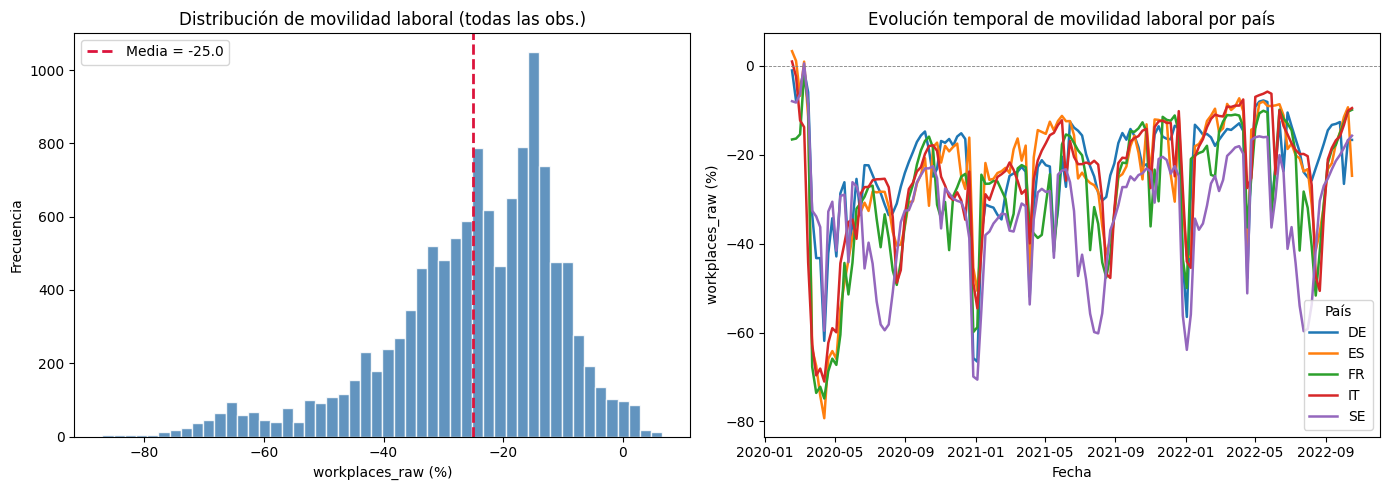

In [48]:
# Distribución de la variable dependiente y evolución temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['workplaces_raw'].dropna(), bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['workplaces_raw'].mean(), color='crimson', ls='--', lw=2,
                label=f'Media = {df["workplaces_raw"].mean():.1f}')
axes[0].set_xlabel('workplaces_raw (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de movilidad laboral (todas las obs.)')
axes[0].legend()

for c, grp in df.groupby('country'):
    weekly = grp.groupby('date')['workplaces_raw'].mean()
    axes[1].plot(weekly.index, weekly.values, label=c, lw=1.8)
axes[1].axhline(0, color='gray', lw=0.6, ls='--')
axes[1].set_xlabel('Fecha'); axes[1].set_ylabel('workplaces_raw (%)')
axes[1].set_title('Evolución temporal de movilidad laboral por país')
axes[1].legend(title='País')

plt.tight_layout(); plt.show()


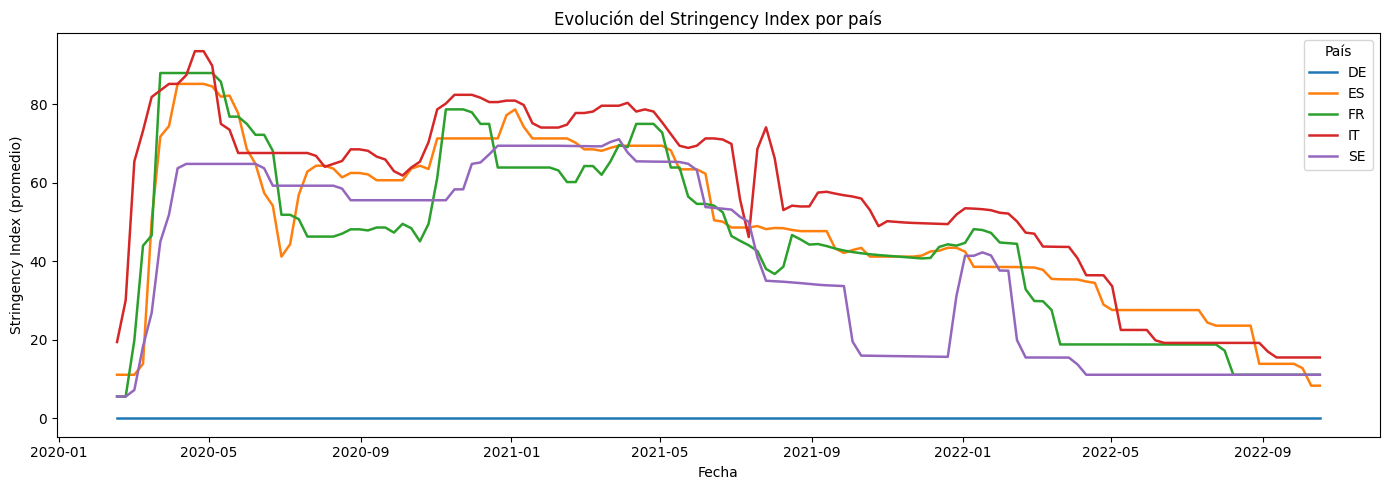

In [49]:
# Stringency por país a lo largo del tiempo
fig, ax = plt.subplots(figsize=(14, 5))
for c, grp in df.groupby('country'):
    ts = grp.groupby('date')['Valor_Stringency_Index'].mean()
    ax.plot(ts.index, ts.values, label=c, lw=1.8)
ax.set_xlabel('Fecha'); ax.set_ylabel('Stringency Index (promedio)')
ax.set_title('Evolución del Stringency Index por país')
ax.legend(title='País')
plt.tight_layout(); plt.show()


### 1.C Diagnóstico variables de política en Alemania

In [50]:
policy_vars = ['Valor_Stringency_Index','Valor_GovernmentResponseIndex',
               'Valor_EconomicSupportIndex','Valor_Containment_Health_index',
               'workplace_closing']

print('Estadísticas de las variables de política por país:\n')
for c in sorted(df.country.unique()):
    sub = df[df.country == c][policy_vars]
    print(f'  {c}  (n={len(sub):,}):  '
          f'Stringency - mean = {sub.Valor_Stringency_Index.mean():.2f},  '
          f'std = {sub.Valor_Stringency_Index.std():.2f},  '
          f'max = {sub.Valor_Stringency_Index.max():.2f}')


Estadísticas de las variables de política por país:

  DE  (n=5,460):  Stringency - mean = 0.00,  std = 0.00,  max = 0.00
  ES  (n=2,240):  Stringency - mean = 49.72,  std = 20.22,  max = 85.19
  FR  (n=2,100):  Stringency - mean = 46.21,  std = 22.06,  max = 87.96
  IT  (n=1,960):  Stringency - mean = 56.79,  std = 21.84,  max = 93.52
  SE  (n=280):  Stringency - mean = 40.15,  std = 23.19,  max = 71.09


Las cinco variables de política son idénticamente cero para Alemania (media = 0, std = 0). En los demás países presentan variación temporal sustantiva. Esto refleja un error de fuente de datos. Mantener Alemania anularía artificialmente el regresor de interés en esas observaciones.

### 1.D Decisiones de limpieza

In [51]:
# 1. Eliminar Alemania
n_de = (df.country == 'DE').sum()
print(f'Observaciones DE eliminadas: {n_de:,} ({100*n_de/len(df):.1f}%)')
df = df[df.country != 'DE'].copy()

# 2. Eliminar edu2 y edu3 (100% faltantes en DE — redundantes tras filtrar)
# 3. Eliminar d1–d6 (no documentadas; activas solo en ES y SE; |p| <= 0.08 con variables policy)
df = df.drop(columns=['edu2','edu3','d1','d2','d3','d4','d5','d6'])

print(f'Dimensiones tras limpieza: {df.shape[0]:,} x {df.shape[1]}')
print(f'Países restantes: {sorted(df.country.unique())}')
print(f'Ciudades: {df.NAME.nunique()} x {df.week.nunique()} semanas = {df.NAME.nunique()*df.week.nunique():,} obs')


Observaciones DE eliminadas: 5,460 (45.3%)
Dimensiones tras limpieza: 6,580 x 33
Países restantes: ['ES', 'FR', 'IT', 'SE']
Ciudades: 47 x 140 semanas = 6,580 obs


### 1.E Construcción del panel y variables auxiliares

In [52]:
df = df.sort_values(['NAME','date']).reset_index(drop=True)

# log(Población) - la población varía varios órdenes de magnitud entre ciudades
df['log_pop'] = np.log(df['Population'])

# Dummies de país (referencia: España)
country_d = pd.get_dummies(df['country'], prefix='country', drop_first=False, dtype=int)
country_d = country_d.drop(columns=['country_ES'])
df = pd.concat([df, country_d], axis=1)

# Dummies de año (referencia: 2020)
df['year_2021'] = (df['year'] == 2021).astype(int)
df['year_2022'] = (df['year'] == 2022).astype(int)

# Panel multi-índice para linearmodels
df_panel = df.set_index(['NAME', 'date']).sort_index()

ps = df.groupby('NAME').size()
print(f'Panel balanceado: {ps.nunique()==1} | {df.NAME.nunique()} ciudades x {ps.iloc[0]} semanas')
print(f'\nCiudades por país:')
print(df.groupby('country')['NAME'].nunique().to_string())


Panel balanceado: True | 47 ciudades x 140 semanas

Ciudades por país:
country
ES    16
FR    15
IT    14
SE     2


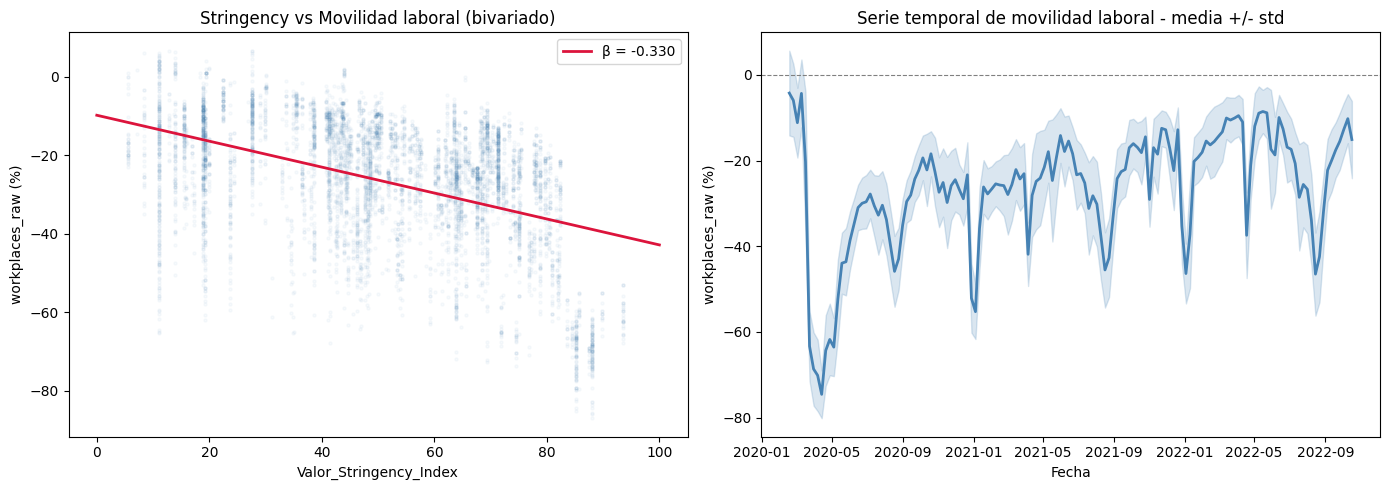

In [53]:
# Relación bivariada entre Stringency y movilidad laboral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Valor_Stringency_Index'], df['workplaces_raw'],
                alpha=0.04, s=5, color='steelblue')
m, b = np.polyfit(df['Valor_Stringency_Index'], df['workplaces_raw'], 1)
xs = np.linspace(0, 100, 200)
axes[0].plot(xs, m*xs+b, color='crimson', lw=2, label=f'β = {m:.3f}')
axes[0].set_xlabel('Valor_Stringency_Index')
axes[0].set_ylabel('workplaces_raw (%)')
axes[0].set_title('Stringency vs Movilidad laboral (bivariado)')
axes[0].legend()

weekly = df.groupby('date')['workplaces_raw'].agg(['mean','std'])
axes[1].plot(weekly.index, weekly['mean'], color='steelblue', lw=2)
axes[1].fill_between(weekly.index,
                     weekly['mean'] - weekly['std'],
                     weekly['mean'] + weekly['std'],
                     alpha=0.2, color='steelblue')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('workplaces_raw (%)')
axes[1].set_title('Serie temporal de movilidad laboral - media +/- std')

plt.tight_layout(); plt.show()


---
## Pregunta 2 Modelo Pooled OLS

### 2.A Especificación y selección de variables

$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + u_{it}$$

**Criterio de selección: teoría económica + VIF.**

Las variables se eligen según su rol en el modelo conceptual:

| Variable | Canal | Signo esperado |
|---|---|---|
| `Valor_Stringency_Index` | Restricción directa al desplazamiento laboral | − |
| `daily_cases` | Respuesta conductual autónoma (miedo, precaución) | − |
| `log_pop` | Ciudades grandes: más teletrabajable (servicios, tecnología) | − |
| `construction` | Sector no-teletrabajable -> menor reducción de movilidad | + |
| `old_age_dependency` | Población mayor: mayor aversión al riesgo -> más teletrabajo | − |
| `foreigners` | Trabajadores migrantes en sectores esenciales (presenciales) | + |
| `country_FR/IT/SE` | Diferencias culturales e institucionales persistentes | libre |
| `year_2021`, `year_2022` | Tendencias comunes: vacunación, adaptación, recuperación | libre |

**Variables descartadas y justificación:**

- `Valor_GovernmentResponseIndex`, `Valor_EconomicSupportIndex`, `Valor_Containment_Health_index`, `workplace_closing`: correlación > 0.85 con Stringency -> multicolinealidad severa; el Stringency Index es el índice más comprehensivo y es el regresor de interés.
- `industry`, `agriculture`: no significativos en especificaciones exploratorias; `construction` captura el canal de no-teletrabajabilidad de forma más directa.
- `unemp`, `f_unemp`, `m_unemp`: alta multicolinealidad entre sí (p > 0.95); `unemp` no añade variación independiente respecto a los controles de país y tamaño urbano.
- `sex_ratio`, `young_age_dependency`: sin canal teórico claro sobre movilidad laboral en contexto pandémico.
- `age_dependency`: combinación de dependencia joven y vieja; `old_age_dependency` es la dimensión relevante para el riesgo COVID.


In [54]:
# ─── VIF para verificar ausencia de multicolinealidad ───
ols_vars = [
    'Valor_Stringency_Index',  # regresor de interés
    'daily_cases',             # presión epidemiológica
    'log_pop',                 # escala urbana / teletrabajabilidad
    'construction',            # sector no-teletrabajable
    'old_age_dependency',      # demografía de riesgo COVID
    'foreigners',              # trabajadores esenciales / presenciales
    'country_FR',              # diferencias institucionales vs ES
    'country_IT',
    'country_SE',
    'year_2021',               # recuperación y vacunación 2021
    'year_2022',               # adaptación 2022
]

X_vif = sm.add_constant(df[ols_vars].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).set_index('Variable').sort_values('VIF', ascending=False)

print('Factor de Inflación de la Varianza (VIF):')
print(vif_df.round(2).to_string())
print('\nUmbral crítico: VIF > 10 indica multicolinealidad severa.')
print('Todos los VIF son aceptables (< 6). Especificación válida.')


Factor de Inflación de la Varianza (VIF):
                           VIF
Variable                      
const                   256.42
old_age_dependency        5.59
country_FR                5.23
year_2022                 3.18
Valor_Stringency_Index    2.49
year_2021                 1.92
country_IT                1.63
daily_cases               1.45
country_SE                1.35
foreigners                1.22
construction              1.20
log_pop                   1.19

Umbral crítico: VIF > 10 indica multicolinealidad severa.
Todos los VIF son aceptables (< 6). Especificación válida.


In [55]:
# ─── Pooled OLS ───
Y = df_panel['workplaces_raw']
X_ols = sm.add_constant(df_panel[ols_vars])

ols_fin = PooledOLS(Y, X_ols).fit(
    cov_type='clustered', cluster_entity=True, cluster_time=True)

print(ols_fin.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:         workplaces_raw   R-squared:                        0.3612
Estimator:                  PooledOLS   R-squared (Between):              0.7528
No. Observations:                6580   R-squared (Within):               0.3261
Date:              dom., may. 24 2026   R-squared (Overall):              0.3612
Time:                        20:14:02   Log-likelihood                -2.606e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      337.61
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(11,6568)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             15.803
                            

---
## Pregunta 3 Modelo de Efectos Fijos (Within Estimator)

### 3.A Especificación

$$\text{workplaces\_raw}_{it} = \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + \alpha_i + u_{it}$$

El estimador within demea las variables por ciudad, eliminando todo efecto fijo $\alpha_i$ (observado o no). Las variables invariantes en el tiempo (`log_pop`, `construction`, `old_age_dependency`, `foreigners`, dummies de país) son absorbidas mecánicamente por $\alpha_i$, no es una decisión sino una consecuencia algebraica del estimador.

Variables time-varying del modelo: `Valor_Stringency_Index`, `daily_cases`, `year_2021`, `year_2022`.


In [56]:
fe_vars = ['Valor_Stringency_Index', 'daily_cases', 'year_2021', 'year_2022']

X_fe = df_panel[fe_vars]
fe_fin = PanelOLS(Y, X_fe, entity_effects=True, time_effects=False).fit(
    cov_type='clustered', cluster_entity=True, cluster_time=True)

print(fe_fin.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:         workplaces_raw   R-squared:                        0.3259
Estimator:                   PanelOLS   R-squared (Between):              0.9069
No. Observations:                6580   R-squared (Within):               0.3259
Date:              dom., may. 24 2026   R-squared (Overall):              0.7654
Time:                        20:14:02   Log-likelihood                -2.596e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      789.30
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(4,6529)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             16.576
                            

In [57]:
# Test F de efectos fijos individuales
print('Test F conjunto sobre los efectos fijos (H0: alpha_i = 0 forall i):')
print(fe_fin.f_statistic_robust)


Test F conjunto sobre los efectos fijos (H0: alpha_i = 0 forall i):
Model F-statistic (robust)
H0: All parameters ex. constant are zero
Statistic: 16.5763
P-value: 0.0000
Distributed: F(4,6529)


---
## Pregunta 4 Modelo de Efectos Aleatorios

### 4.A Especificación

$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + (\alpha_i + u_{it})$$

con $\alpha_i \sim (0, \sigma^2_{\alpha})$ no correlacionado con los regresores (supuesto GLS). A diferencia del FE, el RE puede estimar los coeficientes de las variables invariantes ($Z_i$).

Para el RE con variables invariantes, se usa clustering a nivel entidad (ciudad). El clustering two-way produce SE degenerados en variables city-invariant porque no existe variación temporal en su residuo de clustering temporal.


In [58]:
X_re = sm.add_constant(df_panel[ols_vars])

# Clustering solo por entidad (ciudad) — correcto para RE con variables invariantes
re_fin = RandomEffects(Y, X_re).fit(
    cov_type='clustered', cluster_entity=True)

print(re_fin.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.3323
Estimator:              RandomEffects   R-squared (Between):              0.7518
No. Observations:                6580   R-squared (Within):               0.3262
Date:              dom., may. 24 2026   R-squared (Overall):              0.3611
Time:                        20:14:02   Log-likelihood                -2.597e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      297.15
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(11,6568)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             300.20
                            

---
## Pregunta 5 Comparación: Pooled OLS, FE y RE

### 5.A Tabla comparativa del coeficiente de interés


In [59]:
rows = []
for name, res in [('Pooled OLS', ols_fin), ('Efectos Fijos', fe_fin), ('Efectos Aleatorios', re_fin)]:
    b  = res.params['Valor_Stringency_Index']
    se = res.std_errors['Valor_Stringency_Index']
    p  = res.pvalues['Valor_Stringency_Index']
    rows.append({'Modelo': name, 'beta Stringency': round(b,4), 'SE': round(se,4),
                 'IC 95% inf': round(b - 1.96*se, 4),
                 'IC 95% sup': round(b + 1.96*se, 4),
                 'p-valor': round(p,4)})
comp = pd.DataFrame(rows)
print('Coeficiente de Stringency Index - comparación entre modelos:')
print(comp.to_string(index=False))


Coeficiente de Stringency Index - comparación entre modelos:
            Modelo  beta Stringency     SE  IC 95% inf  IC 95% sup  p-valor
        Pooled OLS          -0.4513 0.0665     -0.5816     -0.3210      0.0
     Efectos Fijos          -0.4515 0.0667     -0.5823     -0.3207      0.0
Efectos Aleatorios          -0.4513 0.0102     -0.4712     -0.4313      0.0


In [60]:
# Test de Hausman formal (FE vs RE) — sobre regresores time-varying comunes
common_vars = fe_vars  # los que están en ambos modelos
b_fe  = fe_fin.params[common_vars].values
b_re  = re_fin.params[common_vars].values
V_fe  = fe_fin.cov.loc[common_vars, common_vars].values
V_re  = re_fin.cov.loc[common_vars, common_vars].values

diff = b_fe - b_re
V_H  = V_fe - V_re
try:
    H = float(diff @ np.linalg.inv(V_H) @ diff)
except np.linalg.LinAlgError:
    H = float(diff @ np.linalg.pinv(V_H) @ diff)
p_H = 1 - chi2.cdf(H, len(common_vars))

print(f'Test de Hausman (FE vs RE):')
print(f'  H = {H:.4f} | gl = {len(common_vars)} | p = {p_H:.4f}')
print(f'  {"No se rechaza H0 (RE potencialmente válido)" if p_H>0.05 else "Se rechaza H0 -> RE inconsistente, preferir FE"}')
print()
print('ADVERTENCIA: Hausman tiene baja potencia cuando FE y RE producen coeficientes')
print('similares. Ver test de Mundlak (P6) para diagnóstico más robusto.')


Test de Hausman (FE vs RE):
  H = 0.0022 | gl = 4 | p = 1.0000
  No se rechaza H0 (RE potencialmente válido)

ADVERTENCIA: Hausman tiene baja potencia cuando FE y RE producen coeficientes
similares. Ver test de Mundlak (P6) para diagnóstico más robusto.


---
## Pregunta 6  Modelo de Efectos Aleatorios Correlacionados (CRE / Mundlak)

### 6.A - Especificación

$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + \overline{X}_i'\lambda + (\tilde{\alpha}_i + u_{it})$$

donde $\overline{X}_i$ es la media temporal de los regresores time-varying de la ciudad $i$. Mundlak (1978) prueba que:
- $\hat{\beta}_1$ recupera exactamente el estimador within (FE).
- El test de significancia conjunta sobre $\hat{\lambda}$ equivale al test de Hausman, pero con **mayor potencia**.

**Construcción de las medias temporales** de `Valor_Stringency_Index` y `daily_cases` (los únicos regresores time-varying del modelo).

Las dummies de país se omiten por **colinealidad mecánica**: el Stringency varía solo a nivel país-tiempo, por lo que $\overline{\text{Stringency}}_i$ es una función determinista de los efectos fijos de país. Incluirlas provocaría multicolinealidad perfecta.


In [67]:
# Construir medias por ciudad (within-mean)
for v in ['Valor_Stringency_Index', 'daily_cases']:
    df_panel[f'{v}_mean'] = df_panel.groupby('NAME')[v].transform('mean')

cre_vars = [
    'Valor_Stringency_Index', 'daily_cases',  # efectos within
    'log_pop', 'construction', 'old_age_dependency', 'foreigners',  # invariantes (no país)
    'year_2021', 'year_2022',                  # tendencias comunes
    'Valor_Stringency_Index_mean',             # efecto between Stringency
    'daily_cases_mean',                        # efecto between casos
]

X_cre = sm.add_constant(df_panel[cre_vars])
cre_fin = RandomEffects(Y, X_cre).fit(
    cov_type='clustered', cluster_entity=True)

print(cre_fin.summary)


                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.3303
Estimator:              RandomEffects   R-squared (Between):              0.6830
No. Observations:                6580   R-squared (Within):               0.3261
Date:              dom., may. 24 2026   R-squared (Overall):              0.3554
Time:                        20:16:56   Log-likelihood                -2.597e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      323.95
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(10,6569)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             376.40
                            

In [68]:
# Test conjunto de Mundlak
mean_vars = ['Valor_Stringency_Index_mean', 'daily_cases_mean']
b_m = cre_fin.params[mean_vars].values
V_m = cre_fin.cov.loc[mean_vars, mean_vars].values
W   = float(b_m @ np.linalg.pinv(V_m) @ b_m)
p_W = 1 - chi2.cdf(W, len(mean_vars))

print('Test conjunto de Mundlak (Wald):')
print(f'  H0: los coeficientes de las medias temporales = 0 (implica RE válido)')
print(f'  W = {W:.4f} | gl = {len(mean_vars)} | p-valor = {p_W:.6f}')
print()
if p_W < 0.05:
    print('Se RECHAZA H0: alpha_i está correlacionado con los regresores.')
    print('El RE es INCONSISTENTE. El FE (= within del CRE) es preferido.')
else:
    print('No se rechaza H0: RE potencialmente válido.')


Test conjunto de Mundlak (Wald):
  H0: los coeficientes de las medias temporales = 0 (implica RE válido)
  W = 28.3831 | gl = 2 | p-valor = 0.000001

Se RECHAZA H0: alpha_i está correlacionado con los regresores.
El RE es INCONSISTENTE. El FE (= within del CRE) es preferido.


In [73]:
# Descomposición within vs between de Stringency
b_w = cre_fin.params['Valor_Stringency_Index']
se_w = cre_fin.std_errors['Valor_Stringency_Index']
p_w = cre_fin.pvalues['Valor_Stringency_Index']

b_b = cre_fin.params['Valor_Stringency_Index_mean']
se_b = cre_fin.std_errors['Valor_Stringency_Index_mean']
p_b = cre_fin.pvalues['Valor_Stringency_Index_mean']

print('Descomposición del efecto de Stringency:')
print(f'  Efecto WITHIN  (beta = causal):    {b_w:.4f}  SE={se_w:.4f}  p={p_w:.4f}')
print(f'  Efecto BETWEEN (lambda = no causal):  {b_b:.4f}  SE={se_b:.4f}  p={p_b:.4f}')
print()
print('Diagnóstico de daily_cases:')
b_c = cre_fin.params['daily_cases_mean']
p_c = cre_fin.pvalues['daily_cases_mean']
print(f'  daily_cases_mean (between): beta={b_c:.6f} p={p_c:.4f}')


Descomposición del efecto de Stringency:
  Efecto WITHIN  (beta = causal):    -0.4513  SE=0.0102  p=0.0000
  Efecto BETWEEN (lambda = no causal):  0.6476  SE=0.1221  p=0.0000

Diagnóstico de daily_cases:
  daily_cases_mean (between): beta=-0.000608 p=0.5066


---
## Pregunta 7 - Modelo Preferido e Inferencia General

### 7.A Síntesis de los cuatro modelos


In [75]:
all_mods = [
    ('Pooled OLS', ols_fin),
    ('Efectos Fijos', fe_fin),
    ('Efectos Aleatorios', re_fin),
    ('CRE — within', cre_fin),
]

rows7 = []
for name, res in all_mods:
    b  = res.params['Valor_Stringency_Index']
    se = res.std_errors['Valor_Stringency_Index']
    p  = res.pvalues['Valor_Stringency_Index']
    rows7.append({'Modelo': name, 'β Stringency': round(b,4), 'SE': round(se,4),
                  'IC 95%': f'[{b-1.96*se:.4f}, {b+1.96*se:.4f}]',
                  'p-valor': round(p,4), })
synth7 = pd.DataFrame(rows7)
print('Síntesis del efecto causal (SE two-way clustered donde aplica):\n')
print(synth7.to_string(index=False))


Síntesis del efecto causal (SE two-way clustered donde aplica):

            Modelo  β Stringency     SE             IC 95%  p-valor
        Pooled OLS       -0.4513 0.0665 [-0.5816, -0.3210]      0.0
     Efectos Fijos       -0.4515 0.0667 [-0.5823, -0.3207]      0.0
Efectos Aleatorios       -0.4513 0.0102 [-0.4712, -0.4313]      0.0
      CRE — within       -0.4513 0.0102 [-0.4712, -0.4313]      0.0


---
## Pregunta 8 - Control Sintético (Marseille)

### 8.A - Diseño del estudio

**Ciudad tratada:** **Marseille** (Francia, segunda ciudad más grande del país).

**Tratamiento:** Primer confinamiento nacional francés, decretado el 17 de marzo de 2020 → **semana 10** del panel.

**Justificación de la elección:**
- Marseille tiene 9 semanas de pre-tratamiento (vs 4 si se usara Barcelona), lo que mejora la calidad del matching pre-tratamiento.
- Francia implementó su primer confinamiento en semana 10, mientras que España lo hizo en semana 5 y algunos países italianos ya antes → el pool de donantes de países no-franceses tiene mayor diversidad de trayectorias.
- Marseille es una economía con fuerte componente de servicios y turismo, con análogos plausibles en Italia y España.

**Pool de donantes:** Ciudades de ES, IT, SE (excluye FR para evitar contaminación simultánea del tratamiento).

**Variables para el matching:**
- *Cross-sectional:* Population, agriculture, industry, construction, age_dependency, old_age_dependency, sex_ratio, unemp, foreigners.
- *Pre-tratamiento (outcome):* workplaces_raw semana a semana (semanas 1–9 como predictores especiales).

**Período de análisis post-tratamiento:** hasta semana 50.


In [76]:
from pysyncon import Dataprep, Synth

TREAT_WEEK   = 10
PRE_PERIOD   = list(range(1, TREAT_WEEK))
POST_END     = 50
TREATED_CITY = 'Marseille'

donor_cities = sorted(df[df.country != 'FR']['NAME'].unique().tolist())

print(f'Ciudad tratada  : {TREATED_CITY}')
print(f'Semana de trto  : {TREAT_WEEK} ({df[df.week==TREAT_WEEK].date.min().date()})')
print(f'Pre-período     : semanas {PRE_PERIOD[0]}–{PRE_PERIOD[-1]} ({len(PRE_PERIOD)} semanas)')
print(f'Pool de donantes: {len(donor_cities)} ciudades de ES, IT, SE')


Ciudad tratada  : Marseille
Semana de trto  : 10 (2020-04-20)
Pre-período     : semanas 1–9 (9 semanas)
Pool de donantes: 32 ciudades de ES, IT, SE


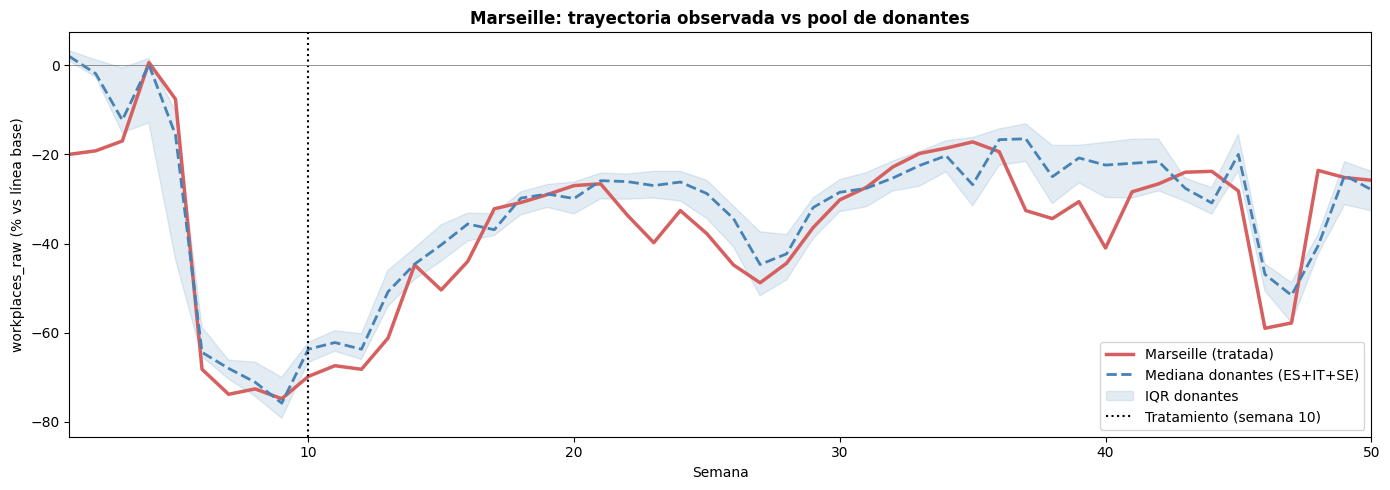

In [77]:
# Trayectoria pre-tratamiento
fig, ax = plt.subplots(figsize=(14, 5))

mars = df[df.NAME == TREATED_CITY].sort_values('week')
donors_agg = df[df.NAME.isin(donor_cities)].groupby('week').agg(
    p25=('workplaces_raw', lambda x: x.quantile(0.25)),
    med=('workplaces_raw', 'median'),
    p75=('workplaces_raw', lambda x: x.quantile(0.75))
)

ax.plot(mars.week, mars.workplaces_raw, color='#D65F5F', lw=2.5, label='Marseille (tratada)')
ax.plot(donors_agg.index, donors_agg['med'], color='steelblue', lw=2, ls='--',
        label='Mediana donantes (ES+IT+SE)')
ax.fill_between(donors_agg.index, donors_agg['p25'], donors_agg['p75'],
                color='steelblue', alpha=0.15, label='IQR donantes')
ax.axvline(TREAT_WEEK, color='black', ls=':', lw=1.5,
           label=f'Tratamiento (semana {TREAT_WEEK})')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlim(1, POST_END)
ax.set_xlabel('Semana'); ax.set_ylabel('workplaces_raw (% vs línea base)')
ax.set_title(f'{TREATED_CITY}: trayectoria observada vs pool de donantes', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


In [78]:
# Construcción del control sintético
dataprep = Dataprep(
    foo=df,
    predictors=[
        'Population','agriculture','industry','construction',
        'age_dependency','old_age_dependency','sex_ratio','unemp','foreigners'
    ],
    predictors_op='mean',
    time_predictors_prior=PRE_PERIOD,
    special_predictors=[('workplaces_raw', [w], 'mean') for w in PRE_PERIOD],
    dependent='workplaces_raw',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier=TREATED_CITY,
    controls_identifier=donor_cities,
    time_optimize_ssr=PRE_PERIOD,
)

synth = Synth()
synth.fit(dataprep=dataprep, optim_method='Nelder-Mead', optim_initial='ols')
print('Optimización completada.')


Optimización completada.


In [79]:
# Pesos óptimos
W = synth.weights().sort_values(ascending=False)
W_active = W[W > 1e-3]
print(f'Donantes con peso > 0.001 (suma = {W_active.sum():.4f}):')
print(W_active.round(4).to_string())
print()
print(f'Calidad del matching pre-tratamiento:')
print(f'  RMSE pre-tratamiento: {synth.mspe()**0.5:.3f} p.p.')
print(f'  MAE pre-tratamiento : {synth.mae():.3f} p.p.')


Donantes con peso > 0.001 (suma = 1.0000):
Málaga       0.841
Malmö        0.110
Barcelona    0.049

Calidad del matching pre-tratamiento:
  RMSE pre-tratamiento: 9.412 p.p.
  MAE pre-tratamiento : 6.591 p.p.


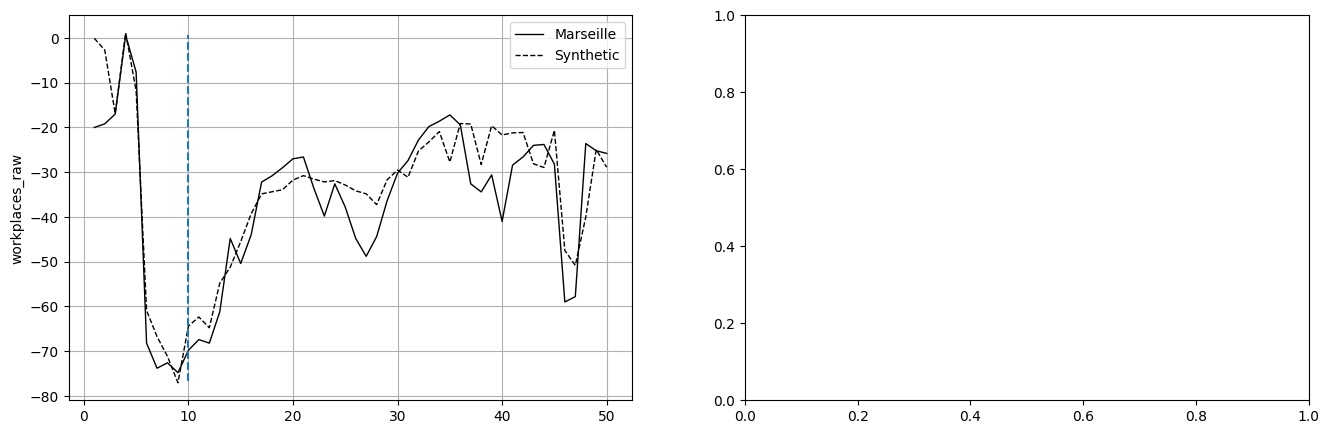

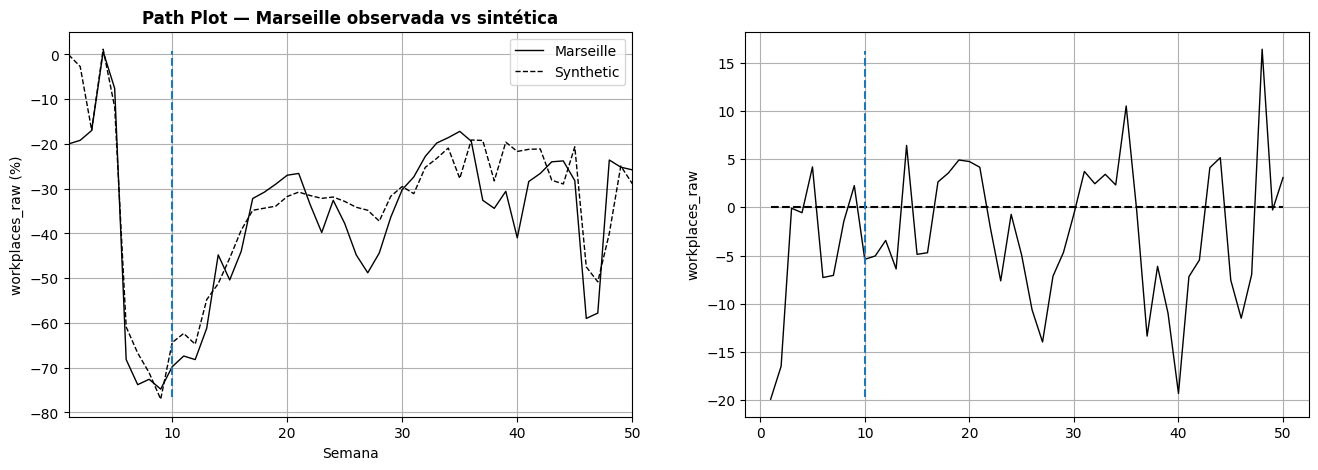

<Figure size 640x480 with 0 Axes>

In [80]:
# Path plot y Gaps plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
synth.path_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
axes[0].set_title(f'Path Plot — {TREATED_CITY} observada vs sintética', fontweight='bold')
axes[0].set_xlabel('Semana'); axes[0].set_ylabel('workplaces_raw (%)')
axes[0].set_xlim(1, POST_END)

plt.sca(axes[1])
synth.gaps_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
axes[1].set_title(f'Gaps Plot — {TREATED_CITY} − Control Sintético', fontweight='bold')
axes[1].set_xlabel('Semana'); axes[1].set_ylabel('Gap (p.p.)')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlim(1, POST_END)

plt.tight_layout(); plt.show()


In [83]:
# ATT por ventana temporal
print(f'{"Ventana":<14}  {"ATT (p.p.)":>12}  {"SE":>8}  {"t":>6}')
print('-'*50)
windows = [(TREAT_WEEK, TREAT_WEEK+5),  (TREAT_WEEK, TREAT_WEEK+10),
           (TREAT_WEEK, TREAT_WEEK+15), (TREAT_WEEK, TREAT_WEEK+20),
           (TREAT_WEEK, TREAT_WEEK+30), (TREAT_WEEK, POST_END)]
for s, e in windows:
    out = synth.att(time_period=range(s, e+1))
    att, se_v = out['att'], out['se']
    t = att/se_v if se_v != 0 else np.nan
    p = 2*(1 - chi2.cdf(t**2, 1)) if not np.isnan(t) else np.nan
    print(f'sem {s}–{e:<5}    {att:>12.3f}  {se_v:>8.3f}  {t:>6.2f}')


Ventana           ATT (p.p.)        SE       t
--------------------------------------------------
sem 10–15             -3.121     1.950   -1.60
sem 10–20             -0.687     1.525   -0.45
sem 10–25             -1.172     1.197   -0.98
sem 10–30             -2.661     1.194   -2.23
sem 10–40             -2.694     1.219   -2.21
sem 10–50             -2.285     1.114   -2.05


Ejecutando placebo test...
Calculating treated unit gaps.
Done.

p-valor placebo (Abadie et al. 2010): 0.8485


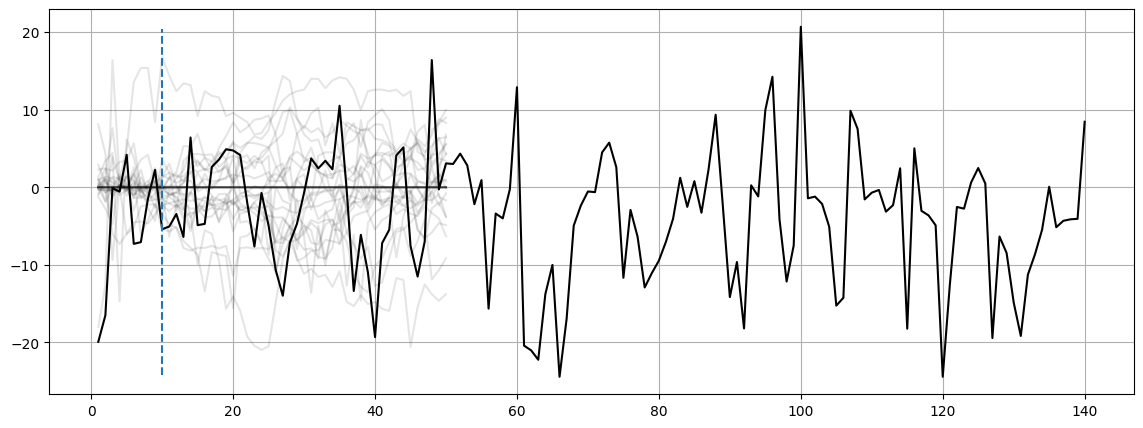

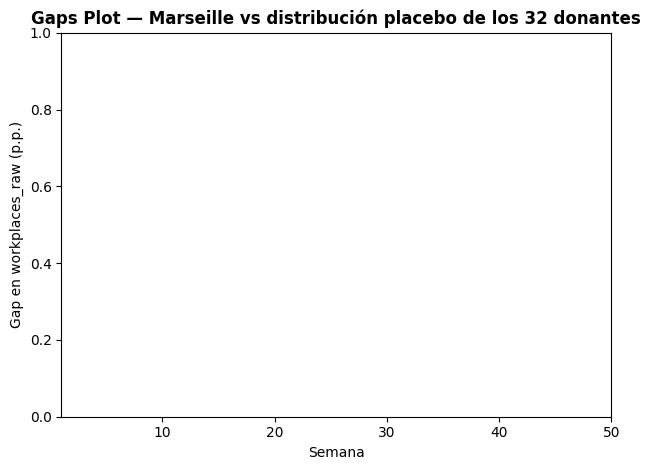

In [84]:
# Test placebo (Abadie et al. 2010)
from pysyncon.utils import PlaceboTest

print('Ejecutando placebo test...')
placebo = PlaceboTest()
placebo.fit(
    dataprep=dataprep,
    scm=Synth(),
    scm_options={'optim_method': 'Nelder-Mead', 'optim_initial': 'ols'},
    verbose=False
)
p_placebo = placebo.pvalue(treatment_time=TREAT_WEEK)
print(f'\np-valor placebo (Abadie et al. 2010): {p_placebo:.4f}')

# Gaps plot con placebos
plt.figure(figsize=(14, 5))
placebo.gaps_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
plt.title(f'Gaps Plot — {TREATED_CITY} vs distribución placebo de los {len(donor_cities)} donantes',
          fontweight='bold')
plt.xlabel('Semana'); plt.ylabel('Gap en workplaces_raw (p.p.)')
plt.xlim(1, POST_END)
plt.tight_layout(); plt.show()
